  3%|▎         | 20/592 [00:22<10:35,  1.11s/it]


KeyboardInterrupt: 

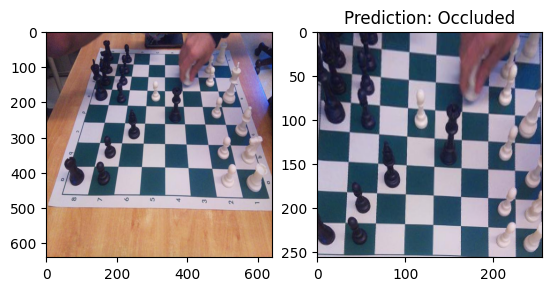

In [1]:
import os

import ChessLens
from OcclusionDetection import OcclusionDetectionCNN

import matplotlib.pyplot as plt
import torch

from tqdm import tqdm

game_dir = "/mnt/D/University/Thesis_Dataset/Temp/video_2/video_14"
model = OcclusionDetectionCNN.OcclusionDetectorCNN()

i = 0
for subdir, _, files in os.walk(game_dir):
    for file in tqdm(files):
        if not (file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg")):
            continue

        img = ChessLens.ChessLensImage(os.path.join(subdir, file))
        img.detect_board()
        warped, _ = img.warp()

        model.set_img(torch.from_numpy(warped).permute(
            2, 0, 1).unsqueeze(0).float() / 255.0)
        res = model.is_occluded()[0]

        plt.subplot(1,2,1)
        plt.imshow(img.img.permute(1, 2, 0))
        plt.subplot(1,2,2)
        plt.imshow(warped)
        plt.title(f"Prediction: {"Occluded" if res else "Valid"}")

        plt.savefig(f"out/out_{i}.jpg")
        i += 1